# Validacion Interna TSTR v5 -- HybridConv1DAutoencoder + Split por Bloques
## Dataset: SWaT A12 (Marzo 2026)

### Diferencias respecto a versiones anteriores

| | v3/v4 | v5 (esta) |
|--|-------|-----------|
| Detector base | conv1d_hybrid_a12 (v1, scaler manana) | **conv1d_hybrid_a12_v2** (nuevo scaler, todas las horas) |
| Split | Cronologico o bloques con scaler incompatible | **Bloques intercalados con scaler correcto** |
| Sinteticos cont | synth_for_detector.npy (escalado con scaler v1) | **synth_all_physical.npy + nuevo scaler v2** |
| Sinteticos disc | synth_disc_raw.npy + disc_max v1 | **synth_disc_raw.npy + disc_max v2** |

### Por que synth_all_physical.npy en lugar de synth_for_detector.npy

synth_for_detector.npy fue generado aplicando el scaler v1 (ajustado solo con la manana).
Al usarlo con el nuevo split (que incluye tarde en val/test), habria una inconsistencia:
los sinteticos estarian en el espacio del scaler v1 pero los reales en el del scaler v2.

synth_all_physical.npy contiene los sinteticos en **escala fisica real** (antes de cualquier scaler).
Al aplicarle el nuevo scaler v2, ambos (sinteticos y reales) quedan en el mismo espacio.
El GAN no se re-ejecuta -- solo se re-escalan los outputs que ya existen.


## 0. Imports

In [1]:
import json
import random
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV      = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
DETECTOR_DIR = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12_v2'  # nuevo scaler
TIMEGAN_DIR  = PROJECT_ROOT / 'models' / 'timegan'   / 'conv1d_hybrid_a12_v4'
RESULTS_DIR  = PROJECT_ROOT / 'artifacts' / 'tstr_internal_validation_a12_v2'
MODELS_DIR   = PROJECT_ROOT / 'models'    / 'detectors' / 'conv1d_tstr_internal_a12_v2'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# synth_all_physical.npy = sinteticos en escala fisica (antes de scaler)
SYNTH_PHYS_PATH = TIMEGAN_DIR / 'synth_all_physical.npy'
SYNTH_DISC_PATH = TIMEGAN_DIR / 'synth_disc_raw.npy'

required = [
    RAW_CSV, SYNTH_PHYS_PATH, SYNTH_DISC_PATH,
    DETECTOR_DIR / 'scaler_cont.pkl',
    DETECTOR_DIR / 'disc_max_dict.pkl',
    DETECTOR_DIR / 'columns_config.json',
    DETECTOR_DIR / 'config.json',
]
all_ok = True
for p in required:
    e = p.exists()
    print(f"  {'OK' if e else 'X '} {p.name}")
    if not e: all_ok = False
if not all_ok: raise FileNotFoundError('Faltan artefactos.')


  OK 11-Mar-2026_0900_1700_labeled.csv
  OK synth_all_physical.npy
  OK synth_disc_raw.npy
  OK scaler_cont.pkl
  OK disc_max_dict.pkl
  OK columns_config.json
  OK config.json


## 2. Cargar config del detector v2

In [4]:
with open(DETECTOR_DIR / 'columns_config.json') as f: col_cfg = json.load(f)
with open(DETECTOR_DIR / 'config.json')          as f: det_cfg = json.load(f)

continuous_cols = col_cfg['continuous_cols']
discrete_cols   = col_cfg['discrete_cols']
feature_cols    = col_cfg['feature_cols']
bp              = det_cfg['model_params']
WINDOW_SIZE     = int(det_cfg['window_size'])
STRIDE          = int(det_cfg['stride'])
ALPHA           = float(det_cfg['alpha'])
BLOCK_MINUTES   = int(det_cfg.get('block_minutes', 20))
SCENARIOS       = det_cfg['scenarios']

# Cargar scaler y disc_max del detector v2
scaler_cont  = joblib.load(DETECTOR_DIR / 'scaler_cont.pkl')
disc_max_raw = joblib.load(DETECTOR_DIR / 'disc_max_dict.pkl')
disc_max     = pd.Series(disc_max_raw).reindex(discrete_cols).replace(0, 1)

print(f'window_size: {WINDOW_SIZE} | stride: {STRIDE} | alpha: {ALPHA:.3f}')
print(f'block_minutes: {BLOCK_MINUTES} | scenarios: {SCENARIOS}')
print(f'continuous: {len(continuous_cols)} | discrete: {len(discrete_cols)}')


window_size: 30 | stride: 5 | alpha: 0.306
block_minutes: 20 | scenarios: ['real_only', 'synthetic_only', 'real_plus_synthetic']
continuous: 31 | discrete: 31


## 3. Cargar CSV, split por bloques y escalar

In [5]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

df_all = df_raw[['t_stamp','attack_label'] + feature_cols].copy()
for col in feature_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace('Bad Input', np.nan), errors='coerce')

WARMUP  = 120
df_work = df_all[df_all['attack_label'] == 0][['t_stamp'] + feature_cols].copy()
df_work = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min() + pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)
print(f'Filas normales post-warmup: {len(df_work)}')


Filas normales post-warmup: 25620


In [6]:
def block_interleaved_split(df_normal, block_minutes=20):
    df     = df_normal.copy().sort_values('t_stamp').reset_index(drop=True)
    t_min  = df['t_stamp'].min()
    df['_block'] = ((df['t_stamp'] - t_min).dt.total_seconds() // (block_minutes*60)).astype(int)
    blocks = sorted(df['_block'].unique())
    asgn   = {b: ('train' if i%5 in [0,1,2] else ('val' if i%5==3 else 'test'))
               for i,b in enumerate(blocks)}
    df['_split'] = df['_block'].map(asgn)
    splits = {s: df[df['_split']==s].drop(columns=['_split']).reset_index(drop=True)
              for s in ['train','val','test']}
    for s in ['train','val','test']:
        h = sorted(splits[s]['t_stamp'].dt.hour.unique().tolist())
        print(f'  {s:<6}: {len(splits[s]):,} filas | horas: {h}')
    return splits['train'], splits['val'], splits['test']


df_train, df_val, df_test = block_interleaved_split(df_work, BLOCK_MINUTES)

modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = scaler_cont.transform(df[continuous_cols].values)
    df[discrete_cols]   = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

print(f'Train cont: [{df_train_sc[continuous_cols].values.min():.2f}, '
      f'{df_train_sc[continuous_cols].values.max():.2f}]  (esperado ~[-3,3])')


  train : 15,780 filas | horas: [9, 10, 11, 12, 13, 14, 15, 16]
  val   : 5,400 filas | horas: [10, 11, 12, 13, 15, 16, 17]
  test  : 4,440 filas | horas: [10, 12, 13, 14, 15]
Train cont: [-7.72, 40.67]  (esperado ~[-3,3])


## 4. Ventanas por bloque

In [7]:
def create_windows(arr, window_size, stride):
    wins = [arr[i:i+window_size] for i in range(0, len(arr)-window_size+1, stride)]
    if not wins: return np.empty((0,window_size,arr.shape[1]),dtype=np.float32)
    return np.array(wins, dtype=np.float32)


def summarize_discrete_windows(disc_windows, discrete_cols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode())>0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)


def build_windows_per_block(df_sc, continuous_cols, discrete_cols,
                            window_size, stride, block_col='_block'):
    all_cont, all_disc = [], []
    for bid in sorted(df_sc[block_col].unique()):
        df_b = df_sc[df_sc[block_col]==bid].reset_index(drop=True)
        if len(df_b) < window_size: continue
        cw = create_windows(df_b[continuous_cols].values.astype(np.float32), window_size, stride)
        dw = create_windows(df_b[discrete_cols].values.astype(np.float32),   window_size, stride)
        if len(cw) == 0: continue
        all_cont.append(np.transpose(cw, (0,2,1)))
        all_disc.append(summarize_discrete_windows(dw, discrete_cols).values.astype(np.float32))
    if not all_cont: return None, None
    return np.concatenate(all_cont, 0), np.concatenate(all_disc, 0)


X_tr_c, X_tr_d = build_windows_per_block(df_train_sc, continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows_per_block(df_val_sc,   continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows_per_block(df_test_sc,  continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)

print(f'Train | cont: {X_tr_c.shape}  disc: {X_tr_d.shape}')
print(f'Val   | cont: {X_va_c.shape}  disc: {X_va_d.shape}')
print(f'Test  | cont: {X_te_c.shape}  disc: {X_te_d.shape}')


Train | cont: (3081, 31, 30)  disc: (3081, 124)
Val   | cont: (1055, 31, 30)  disc: (1055, 124)
Test  | cont: (868, 31, 30)  disc: (868, 124)


## 5. Cargar sinteticos y aplicar nuevo scaler

Se carga synth_all_physical.npy (escala fisica real) y se aplica el nuevo scaler v2.
Esto garantiza que sinteticos y reales esten en exactamente el mismo espacio.


In [8]:
synth_phys_raw = np.load(SYNTH_PHYS_PATH).astype(np.float32)  # (N, 30, 31) escala fisica
synth_disc_raw = np.load(SYNTH_DISC_PATH).astype(np.float32)  # (N, 30, 31) sin escalar

print(f'synth_phys_raw: {synth_phys_raw.shape}  (escala fisica real)')
print(f'synth_disc_raw: {synth_disc_raw.shape}')

assert synth_phys_raw.shape[1] == WINDOW_SIZE
assert synth_phys_raw.shape[2] == len(continuous_cols)
assert synth_disc_raw.shape[2] == len(discrete_cols)

# Aplicar nuevo scaler v2 a las continuas sinteticas
N_synth = synth_phys_raw.shape[0]
synth_cont_scaled = scaler_cont.transform(
    synth_phys_raw.reshape(-1, len(continuous_cols))
).reshape(N_synth, WINDOW_SIZE, len(continuous_cols)).astype(np.float32)

# Transponer: (N, W, C) -> (N, C, W) para Conv1D
X_sy_c = np.transpose(synth_cont_scaled, (0, 2, 1)).astype(np.float32)

# Discretas: aplicar disc_max v2 + clip
synth_disc_scaled = (synth_disc_raw / disc_max.values.reshape(1,1,-1)).clip(0, 1).astype(np.float32)
X_sy_d = summarize_discrete_windows(synth_disc_scaled, discrete_cols).values.astype(np.float32)

print(f'X_sy_c (para Conv1D): {X_sy_c.shape}')
print(f'X_sy_d (para MLP):    {X_sy_d.shape}')
print(f'Rango cont sinteticos escalados: [{X_sy_c.min():.2f}, {X_sy_c.max():.2f}]')
assert X_sy_c.shape[1:] == X_tr_c.shape[1:], 'Shape mismatch cont'
assert X_sy_d.shape[1:] == X_tr_d.shape[1:], 'Shape mismatch disc'
print('Shapes compatibles.')


synth_phys_raw: (5115, 30, 31)  (escala fisica real)
synth_disc_raw: (5115, 30, 31)
X_sy_c (para Conv1D): (5115, 31, 30)
X_sy_d (para MLP):    (5115, 124)
Rango cont sinteticos escalados: [-6.74, 26.78]
Shapes compatibles.


In [9]:
rng = np.random.default_rng(SEED)
n_real = len(X_tr_c)
if len(X_sy_c) > n_real:
    idx = rng.choice(len(X_sy_c), size=n_real, replace=False)
    X_sy_c_used, X_sy_d_used = X_sy_c[idx], X_sy_d[idx]
    print(f'Sinteticos submuestreados: {len(X_sy_c)} -> {n_real}')
else:
    X_sy_c_used, X_sy_d_used = X_sy_c, X_sy_d

X_mx_c = np.concatenate([X_tr_c, X_sy_c_used], 0).astype(np.float32)
X_mx_d = np.concatenate([X_tr_d, X_sy_d_used], 0).astype(np.float32)

print(f'real_only:           cont={X_tr_c.shape}  disc={X_tr_d.shape}')
print(f'synthetic_only:      cont={X_sy_c_used.shape}  disc={X_sy_d_used.shape}')
print(f'real_plus_synthetic: cont={X_mx_c.shape}  disc={X_mx_d.shape}')


Sinteticos submuestreados: 5115 -> 3081
real_only:           cont=(3081, 31, 30)  disc=(3081, 124)
synthetic_only:      cont=(3081, 31, 30)  disc=(3081, 124)
real_plus_synthetic: cont=(6162, 31, 30)  disc=(6162, 124)


## 6. Arquitectura HybridConv1DAutoencoder

In [10]:
class HybridConv1DAutoencoder(nn.Module):
    def __init__(self, cont_channels, seq_len, disc_dim,
                 n_conv_layers=1, conv_channels_1=32, conv_channels_2=16, conv_channels_3=8,
                 kernel_size=3, disc_hidden_1=64, disc_hidden_2=32,
                 fusion_hidden=128, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        channels_list = [cont_channels]
        if n_conv_layers >= 1: channels_list.append(conv_channels_1)
        if n_conv_layers >= 2: channels_list.append(conv_channels_2)
        if n_conv_layers >= 3: channels_list.append(conv_channels_3)
        enc, cur = [], seq_len
        for i in range(len(channels_list)-1):
            enc += [nn.Conv1d(channels_list[i],channels_list[i+1],
                              kernel_size=kernel_size,padding=kernel_size//2),
                    nn.ReLU(),nn.Dropout(dropout),nn.MaxPool1d(2)]
            cur //= 2
        self.encoder_conv = nn.Sequential(*enc)
        self.reduced_len  = cur; self.last_ch = channels_list[-1]
        self.conv_flat    = self.last_ch * cur
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim,disc_hidden_1),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(disc_hidden_1,disc_hidden_2),nn.ReLU())
        self.disc_hidden_2 = disc_hidden_2
        self.fusion = nn.Sequential(
            nn.Linear(self.conv_flat+disc_hidden_2,fusion_hidden),
            nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(fusion_hidden,self.conv_flat+disc_hidden_2))
        rev = list(reversed(channels_list)); dec = []
        for i in range(len(rev)-1):
            dec += [nn.ConvTranspose1d(rev[i],rev[i+1],kernel_size=2,stride=2),
                    nn.ReLU(),nn.Dropout(dropout)]
        dec.append(nn.Conv1d(rev[-1],rev[-1],kernel_size=kernel_size,padding=kernel_size//2))
        self.decoder_conv = nn.Sequential(*dec)
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden_2,disc_hidden_1),nn.ReLU(),
            nn.Linear(disc_hidden_1,disc_dim))

    def forward(self, xc, xd):
        hc = self.encoder_conv(xc).view(xc.size(0),-1)
        hd = self.encoder_disc(xd)
        f  = self.fusion(torch.cat([hc,hd],1))
        hcd = f[:,:self.conv_flat].view(xc.size(0),self.last_ch,self.reduced_len)
        oc = self.decoder_conv(hcd)
        if oc.shape[2] != self.seq_len: oc = oc[:,:,:self.seq_len]
        return oc, self.decoder_disc(f[:,self.conv_flat:])


def hybrid_loss(xc,xc_hat,xd,xd_hat,alpha):
    return alpha*nn.functional.mse_loss(xc_hat,xc)+(1-alpha)*nn.functional.mse_loss(xd_hat,xd)


# Verificar
_m  = HybridConv1DAutoencoder(X_tr_c.shape[1],WINDOW_SIZE,X_tr_d.shape[1],
    n_conv_layers=int(bp['n_conv_layers']),conv_channels_1=int(bp['conv_channels_1']),
    conv_channels_2=int(bp['conv_channels_2']),conv_channels_3=int(bp['conv_channels_3']),
    kernel_size=int(bp['kernel_size']),disc_hidden_1=int(bp['disc_hidden_1']),
    disc_hidden_2=int(bp['disc_hidden_2']),fusion_hidden=int(bp['fusion_hidden']),
    dropout=float(bp['dropout']))
_xc = torch.zeros(2,X_tr_c.shape[1],WINDOW_SIZE)
_xd = torch.zeros(2,X_tr_d.shape[1])
_oc,_od = _m(_xc,_xd)
assert _oc.shape==_xc.shape and _od.shape==_xd.shape
print(f'Arquitectura OK: {sum(p.numel() for p in _m.parameters()):,} params')
del _m,_xc,_xd,_oc,_od


Arquitectura OK: 163,807 params


## 7. Entrenamiento 3 escenarios

In [11]:
def make_loader(Xc, Xd, batch_size, shuffle=True):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(
        TensorDataset(torch.tensor(Xc,dtype=torch.float32),
                      torch.tensor(Xd,dtype=torch.float32)),
        batch_size=batch_size, shuffle=shuffle,
        generator=g if shuffle else None)


def train_scenario(Xc_tr, Xd_tr, name, epochs):
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    model = HybridConv1DAutoencoder(
        Xc_tr.shape[1], WINDOW_SIZE, Xd_tr.shape[1],
        n_conv_layers=int(bp['n_conv_layers']),
        conv_channels_1=int(bp['conv_channels_1']),
        conv_channels_2=int(bp['conv_channels_2']),
        conv_channels_3=int(bp['conv_channels_3']),
        kernel_size=int(bp['kernel_size']),
        disc_hidden_1=int(bp['disc_hidden_1']),
        disc_hidden_2=int(bp['disc_hidden_2']),
        fusion_hidden=int(bp['fusion_hidden']),
        dropout=float(bp['dropout'])).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=float(bp['lr']))
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=10, min_lr=1e-6)
    tr_l  = make_loader(Xc_tr, Xd_tr, int(bp['batch_size']), shuffle=True)
    va_l  = make_loader(X_va_c, X_va_d, int(bp['batch_size']), shuffle=False)

    best_val, best_wts, wait, best_ep = float('inf'), None, 0, 1
    th, vh = [], []

    print(f'\n=== {name} === Train: {Xc_tr.shape}')
    for ep in range(1, epochs+1):
        model.train(); tl=0.0
        for xc,xd in tr_l:
            xc,xd=xc.to(device),xd.to(device)
            opt.zero_grad()
            xc_hat,xd_hat=model(xc,xd)
            loss=hybrid_loss(xc,xc_hat,xd,xd_hat,ALPHA)
            loss.backward(); opt.step(); tl+=loss.item()
        tl/=len(tr_l)
        model.eval(); vl=0.0
        with torch.no_grad():
            for xc,xd in va_l:
                xc,xd=xc.to(device),xd.to(device)
                xc_hat,xd_hat=model(xc,xd)
                vl+=hybrid_loss(xc,xc_hat,xd,xd_hat,ALPHA).item()
        vl/=len(va_l)
        sch.step(vl); th.append(tl); vh.append(vl)
        if vl < best_val-1e-6:
            best_val=vl; best_wts={k:v.clone() for k,v in model.state_dict().items()}
            best_ep=ep; wait=0
        else: wait+=1
        if ep%10==0:
            print(f'  Ep {ep:3d}/{epochs} | Train: {tl:.5f} | Val: {vl:.5f} | Best: {best_val:.5f} (ep {best_ep})')
        if wait >= 20:
            print(f'  Early stopping ep {ep}.')
            break
    model.load_state_dict(best_wts)
    model.eval()
    return model, th, vh


def recon_errors(model, Xc, Xd, alpha, bs=256):
    loader = make_loader(Xc, Xd, bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc,xd in loader:
            xc,xd=xc.to(device),xd.to(device)
            xc_hat,xd_hat=model(xc,xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2,dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2,dim=1).cpu().numpy())
    ec=np.array(ec_l); ed=np.array(ed_l)
    return ec, ed, alpha*ec+(1-alpha)*ed


In [12]:
EPOCHS_MAP = {'real_only':80,'synthetic_only':80,'real_plus_synthetic':150}

SCENARIOS_DATA = {
    'real_only':           (X_tr_c,      X_tr_d),
    'synthetic_only':      (X_sy_c_used, X_sy_d_used),
    'real_plus_synthetic': (X_mx_c,      X_mx_d),
}

models_tstr, histories, all_errors, summary_rows = {}, {}, {}, []

for sc, (Xc_tr, Xd_tr) in SCENARIOS_DATA.items():
    model, th, vh = train_scenario(Xc_tr, Xd_tr, sc, EPOCHS_MAP[sc])
    ec_tr,ed_tr,err_tr = recon_errors(model, Xc_tr,      Xd_tr,      ALPHA)
    ec_va,ed_va,err_va = recon_errors(model, X_va_c,     X_va_d,     ALPHA)
    ec_te,ed_te,err_te = recon_errors(model, X_te_c,     X_te_d,     ALPHA)
    models_tstr[sc]    = model
    histories[sc]      = {'train_loss':th,'val_loss':vh}
    all_errors[sc]     = {'train':err_tr,'val':err_va,'test':err_te,
                          'val_c':ec_va,'val_d':ed_va}
    summary_rows.append({'scenario':sc,'best_val':min(vh),
                         'val_mean':float(err_va.mean()),'val_std':float(err_va.std()),
                         'val_p90':float(np.percentile(err_va,90)),
                         'val_p95':float(np.percentile(err_va,95)),
                         'val_p99':float(np.percentile(err_va,99))})

summary_df = pd.DataFrame(summary_rows)
print('\n=== TABLA RESUMEN ===')
display(summary_df)



=== real_only === Train: (3081, 31, 30)
  Ep  10/80 | Train: 0.09162 | Val: 1.08505 | Best: 1.07220 (ep 7)
  Ep  20/80 | Train: 0.05712 | Val: 0.79250 | Best: 0.79250 (ep 20)
  Ep  30/80 | Train: 0.04281 | Val: 0.40307 | Best: 0.40307 (ep 30)
  Ep  40/80 | Train: 0.03815 | Val: 0.35421 | Best: 0.33588 (ep 39)
  Ep  50/80 | Train: 0.03412 | Val: 0.32137 | Best: 0.30932 (ep 46)
  Ep  60/80 | Train: 0.03363 | Val: 0.33221 | Best: 0.29969 (ep 57)
  Ep  70/80 | Train: 0.02974 | Val: 0.36220 | Best: 0.29188 (ep 67)
  Ep  80/80 | Train: 0.02839 | Val: 0.31899 | Best: 0.27487 (ep 72)

=== synthetic_only === Train: (3081, 31, 30)
  Ep  10/80 | Train: 0.11444 | Val: 1.15371 | Best: 1.15201 (ep 9)
  Ep  20/80 | Train: 0.09364 | Val: 1.11855 | Best: 1.11855 (ep 20)
  Ep  30/80 | Train: 0.08485 | Val: 1.11773 | Best: 1.11518 (ep 25)
  Ep  40/80 | Train: 0.07904 | Val: 1.11626 | Best: 1.11518 (ep 25)
  Early stopping ep 45.

=== real_plus_synthetic === Train: (6162, 31, 30)
  Ep  10/150 | Train: 0.

,scenario,best_val,val_mean,val_std,val_p90,val_p95,val_p99
0,real_only,0.274873,0.277184,0.790913,0.198307,3.167139,3.546201
1,synthetic_only,1.115181,1.142352,3.874788,0.249176,16.440187,17.001528
2,real_plus_synthetic,0.370148,0.373851,1.161911,0.191961,4.885208,5.142229


## 8. Visualizaciones

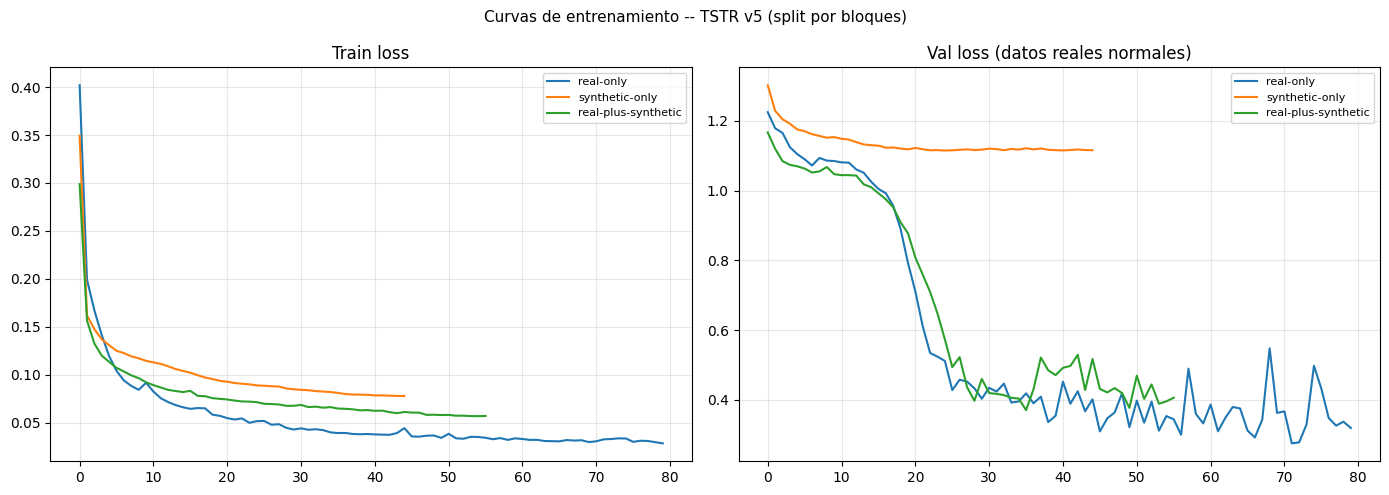

In [13]:
COLORS = {'real_only':'#1f77b4','synthetic_only':'#ff7f0e','real_plus_synthetic':'#2ca02c'}

fig, axes = plt.subplots(1,2,figsize=(14,5))
for sc,hist in histories.items():
    axes[0].plot(hist['train_loss'],color=COLORS[sc],label=sc.replace('_','-'),lw=1.5)
    axes[1].plot(hist['val_loss'],  color=COLORS[sc],label=sc.replace('_','-'),lw=1.5)
for ax,t in zip(axes,['Train loss','Val loss (datos reales normales)']):
    ax.set_title(t); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)
plt.suptitle('Curvas de entrenamiento -- TSTR v5 (split por bloques)', fontsize=11)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR/'training_curves.png'),dpi=120,bbox_inches='tight')
plt.show()


In [14]:
# Tabla de umbrales
tau_rows = []
for sc in SCENARIOS:
    for p in [90,95,97.5,99,99.5]:
        tau_rows.append({'scenario':sc,'percentil':p,
                         'tau':float(np.percentile(all_errors[sc]['val'],p))})
pivot = pd.DataFrame(tau_rows).pivot(index='percentil',columns='scenario',values='tau')[SCENARIOS]
print('Umbrales tau por escenario (val real):')
display(pivot)


Umbrales tau por escenario (val real):


scenario,real_only,synthetic_only,real_plus_synthetic
percentil,,,
90.0,0.198307,0.249176,0.191961
95.0,3.167139,16.440187,4.885208
97.5,3.480565,16.789797,5.054191
99.0,3.546201,17.001528,5.142229
99.5,3.566757,17.087210,5.163605


## 9. Guardar artefactos

In [15]:
summary_df.to_csv(RESULTS_DIR / 'summary_errors.csv', index=False)
joblib.dump(scaler_cont, RESULTS_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max,    RESULTS_DIR / 'disc_max.pkl')
with open(RESULTS_DIR / 'columns_config.json','w') as f:
    json.dump({'continuous_cols':continuous_cols,'discrete_cols':discrete_cols,
               'feature_cols':feature_cols}, f, indent=4)
with open(RESULTS_DIR / 'config.json','w') as f:
    json.dump({'scenarios':SCENARIOS,'window_size':WINDOW_SIZE,'stride':STRIDE,
               'alpha':ALPHA,'block_minutes':BLOCK_MINUTES,
               'epochs_map':EPOCHS_MAP,'model_class':'HybridConv1DAutoencoder',
               'model_params':{k:(float(v) if isinstance(v,float) else v) for k,v in bp.items()},
               'detector_dir':str(DETECTOR_DIR),
               'n_train_real':int(len(X_tr_c)),'n_synth_used':int(len(X_sy_c_used)),
               'n_val':int(len(X_va_c)),'n_test':int(len(X_te_c)),
               'cont_channels':int(X_tr_c.shape[1]),'disc_dim':int(X_tr_d.shape[1])}, f, indent=4)

for sc in SCENARIOS:
    sc_dir = MODELS_DIR / sc
    sc_dir.mkdir(parents=True, exist_ok=True)
    torch.save(models_tstr[sc].state_dict(), sc_dir / 'model_state.pt')
    pd.DataFrame(histories[sc]).to_csv(sc_dir / 'train_history.csv', index=False)
    np.save(sc_dir / 'val_errors.npy',   all_errors[sc]['val'])
    np.save(sc_dir / 'val_errors_c.npy', all_errors[sc]['val_c'])
    np.save(sc_dir / 'val_errors_d.npy', all_errors[sc]['val_d'])
    np.save(sc_dir / 'test_errors.npy',  all_errors[sc]['test'])
    tau_dict = {f'p{str(p).replace(".","_")}':float(np.percentile(all_errors[sc]['val'],p))
                for p in [90,95,97.5,99,99.5]}
    with open(sc_dir / 'tau_dict.json','w') as f: json.dump(tau_dict,f,indent=4)
    with open(sc_dir / 'config.json','w') as f:
        json.dump({'scenario':sc,'model_class':'HybridConv1DAutoencoder',
                   'cont_channels':int(X_tr_c.shape[1]),'disc_dim':int(X_tr_d.shape[1]),
                   'seq_len':WINDOW_SIZE,'window_size':WINDOW_SIZE,'stride':STRIDE,
                   'alpha':ALPHA,'epochs_run':len(histories[sc]['train_loss']),
                   'best_val_loss':float(min(histories[sc]['val_loss'])),
                   'val_error_mean':float(np.mean(all_errors[sc]['val'])),
                   'val_error_p95':float(np.percentile(all_errors[sc]['val'],95)),
                   'tau_dict':tau_dict,'continuous_cols':continuous_cols,
                   'discrete_cols':discrete_cols,'feature_cols':feature_cols,
                   'train_shape_c':list(SCENARIOS_DATA[sc][0].shape)}, f, indent=4)

print('Artefactos guardados en:', MODELS_DIR.resolve())
for sc_dir in sorted(MODELS_DIR.iterdir()):
    print(f'  {sc_dir.name}/  -> {[f.name for f in sorted(sc_dir.iterdir())]}')


Artefactos guardados en: C:\Users\j.manriquec\ics-synthetic-data-augmentation\models\detectors\conv1d_tstr_internal_a12_v2
  real_only/  -> ['config.json', 'model_state.pt', 'tau_dict.json', 'test_errors.npy', 'train_history.csv', 'val_errors.npy', 'val_errors_c.npy', 'val_errors_d.npy']
  real_plus_synthetic/  -> ['config.json', 'model_state.pt', 'tau_dict.json', 'test_errors.npy', 'train_history.csv', 'val_errors.npy', 'val_errors_c.npy', 'val_errors_d.npy']
  synthetic_only/  -> ['config.json', 'model_state.pt', 'tau_dict.json', 'test_errors.npy', 'train_history.csv', 'val_errors.npy', 'val_errors_c.npy', 'val_errors_d.npy']
